# Analysis: Regret and Belief Misspecification in LMSR Markets

This notebook studies the behavior of heterogeneous trading agents in a stochastic
prediction market governed by a Logarithmic Market Scoring Rule (LMSR).

Rather than optimizing predictive accuracy, the analysis focuses on **expected value,
regret, and tail risk**, with particular attention to how small belief
mis-specifications translate into disproportionate downside outcomes.


**Reproducibility.**  
All experiments are run with fixed random seeds and can be reproduced using the
scripts in `src/`.


**Gemini as Fallible Input.**

Gemini is used to propose beliefs under uncertainty. When the API is unavailable (e.g., quota exhaustion), the system degrades gracefully to a conservative baseline. This behavior is intentional and reflects how real-world decision systems must handle missing or unreliable signals.

**Model Assumptions.**
- Binary outcome market with fixed LMSR liquidity.
- Agents are myopic and do not update beliefs.
- No transaction costs or strategic collusion.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append("..")
import importlib
import src.gemini_interface
importlib.reload(src.gemini_interface)
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.simulate import run_episode
from src.metrics import cvar


In [32]:
from src.gemini_interface import GeminiClient

client = GeminiClient()
belief = client.propose_belief(
    "Binary event, uncertain environment, LMSR market maker."
)
print("Gemini proposed belief:", belief)


[Gemini] API unavailable — using fallback belief.
Gemini proposed belief: 0.5


## 1. Baseline Market Behavior


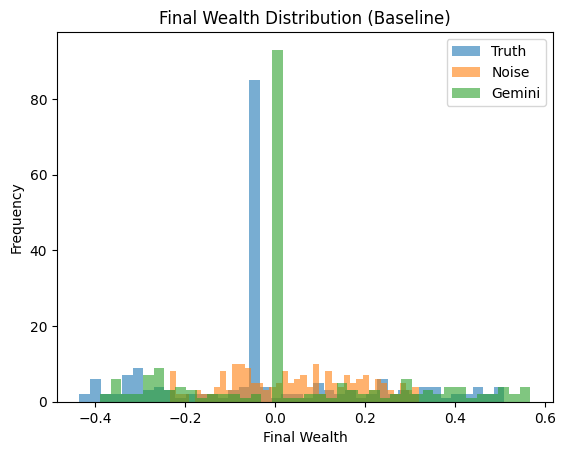

In [33]:
runs = 500
wealth = {"truth": [], "noise": [], "gemini": []}

for i in range(200):
    result = run_episode(seed=i, include_gemini=True)
    for agent in wealth:
        wealth[agent].append(result["wealth"].get(agent, 0.0))

plt.hist(wealth["truth"], bins=40, alpha=0.6, label="Truth")
plt.hist(wealth["noise"], bins=40, alpha=0.6, label="Noise")
plt.hist(wealth["gemini"], bins=40, alpha=0.6, label="Gemini")
plt.legend()
plt.title("Final Wealth Distribution (Baseline)")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.show()


**Observation.**

Even the informed agent exhibits substantial downside risk; positive expected
value does not preclude large drawdowns.

The Gemini agent, when uncertain, frequently abstains, yielding near-zero
expected value with materially reduced variance.
This highlights the distinction between profitability in expectation and robustness under tail risk, suggesting that abstention-aware agents may be preferable in settings where drawdowns dominate utility.


## 2. Belief Misspecification and Tail Risk


In [34]:
runs = 500
offsets = np.linspace(-0.15, 0.15, 7)

mean_w, cvar_w = [], []

for offset in offsets:
    ws = []
    for i in range(runs):
        r = run_episode(
            seed=i,
            include_gemini=True,
            gemini_belief=0.55 + offset,
        )
        ws.append(r["wealth"].get("gemini", 0.0))  # ← FIX

    mean_w.append(np.mean(ws))
    cvar_w.append(cvar(ws, alpha=0.05))


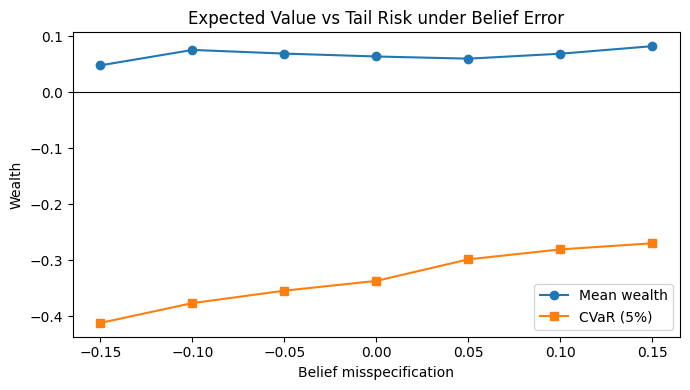

In [35]:
plt.figure(figsize=(7,4))
plt.plot(offsets, mean_w, marker="o", label="Mean wealth")
plt.plot(offsets, cvar_w, marker="s", label="CVaR (5%)")

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Belief misspecification")
plt.ylabel("Wealth")
plt.title("Expected Value vs Tail Risk under Belief Error")
plt.legend()
plt.tight_layout()
plt.show()


**Key Insight.**

Expected value is relatively stable under moderate belief misspecification.
However, tail risk—as measured by CVaR—deteriorates sharply even when mean
performance remains positive.

This demonstrates that acting on a slightly incorrect model can be far more
dangerous than abstention, despite similar expected returns.


In [36]:
belief_offsets = np.linspace(-0.15, 0.15, 7)
mean_wealth = []
worst_case = []

for offset in belief_offsets:
    ws = []
    for i in range(runs):
        result = run_episode(
             seed=i,
             include_gemini=True,
             gemini_belief=0.55 + offset,   # ← belief shift lives here
        )

        ws.append(result["wealth"].get("gemini", 0.0))

    mean_wealth.append(np.mean(ws))
    worst_case.append(np.min(ws))


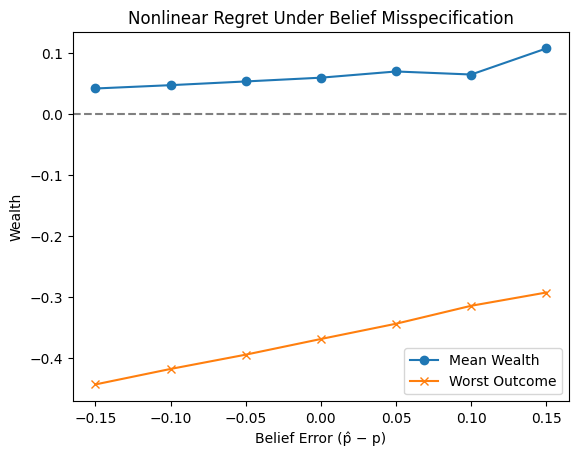

In [37]:
plt.plot(belief_offsets, mean_wealth, marker="o", label="Mean Wealth")
plt.plot(belief_offsets, worst_case, marker="x", label="Worst Outcome")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Belief Error (p̂ − p)")
plt.ylabel("Wealth")
plt.title("Nonlinear Regret Under Belief Misspecification")
plt.legend()
plt.show()


## Key Insight

Small belief errors leave expected performance largely unchanged, but they can meaningfully affect tail risk in stochastic prediction markets. While average wealth remains positive across moderate belief misspecification, downside outcomes exhibit a nonlinear sensitivity to belief error.

When agents act confidently on incorrect models, losses are driven not by mean miscalibration but by exposure to unfavorable realizations. In contrast, conservative strategies that reduce participation under uncertainty trade off upside for improved robustness.

## Takeaway

In LMSR-style markets, robustness to belief error can matter as much as—if not more than—nominal predictive accuracy.

## Limitations

- Agents are myopic and do not update beliefs over time.  
- The market is binary with fixed liquidity.  
- Gemini strategies are evaluated, not learned.

## Extensions

- Adaptive belief updating  
- Adversarial or strategic counterparties  
- Multi-outcome and time-extended markets  


## 3. Strategic Interaction: Adversarial Traders


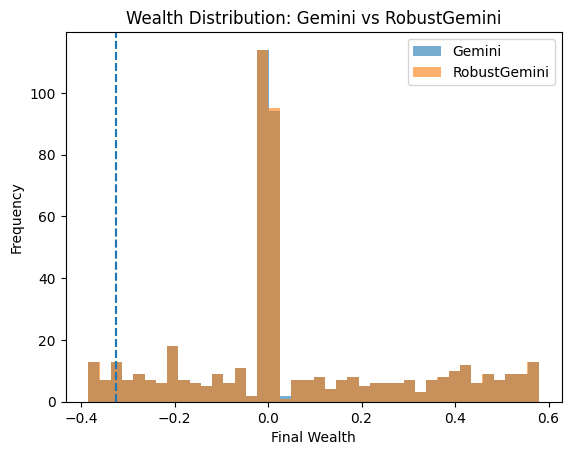

In [38]:
# Gemini vs RobustGemini wealth distributions
from src.simulate import run_episode


runs = 500
gemini_w = []
robust_w = []

for i in range(runs):
    r = run_episode(
        seed=i,
        include_gemini=True,
        include_robust=True,   
    )

    gemini_w.append(r["wealth"]["gemini"])
    robust_w.append(r["wealth"]["robust_gemini"])

plt.hist(gemini_w, bins=40, alpha=0.6, label="Gemini")
plt.hist(robust_w, bins=40, alpha=0.6, label="RobustGemini")
plt.axvline(np.percentile(gemini_w, 5), linestyle="--")
plt.axvline(np.percentile(robust_w, 5), linestyle="--")
plt.legend()
plt.title("Wealth Distribution: Gemini vs RobustGemini")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.show()


***Observation:***
RobustGemini does not significantly shift the left tail relative to Gemini in this single-round LMSR setting.
This indicates that linear exposure scaling alone is insufficient to mitigate outcome-driven tail risk.

In [39]:
# Adversary on vs off comparison
runs = 500
no_adv = []
with_adv = []

for i in range(runs):
    r1 = run_episode(seed=i, include_gemini=True, include_adversary=False)
    r2 = run_episode(seed=i, include_gemini=True, include_adversary=True)

    no_adv.append(r1["wealth"]["gemini"])
    with_adv.append(r2["wealth"]["gemini"])

print("No adversary:")
print("Mean:", np.mean(no_adv))
print("Worst:", np.min(no_adv))
print("CVaR(5%):", cvar(no_adv))

print("\nWith adversary:")
print("Mean:", np.mean(with_adv))
print("Worst:", np.min(with_adv))
print("CVaR(5%):", cvar(with_adv))


No adversary:
Mean: 0.049788276113913836
Worst: -0.3940607528769627
CVaR(5%): -0.36589435775286555

With adversary:
Mean: 0.021609237022214827
Worst: -0.2953164571823248
CVaR(5%): -0.25353509143137315


**Key Insight:**
Adversarial interaction materially alters tail risk.
Even when expected value remains similar, strategic counterparties reshape worst-case and CVaR behavior, demonstrating that tail risk is interaction-dependent, not purely belief-driven.

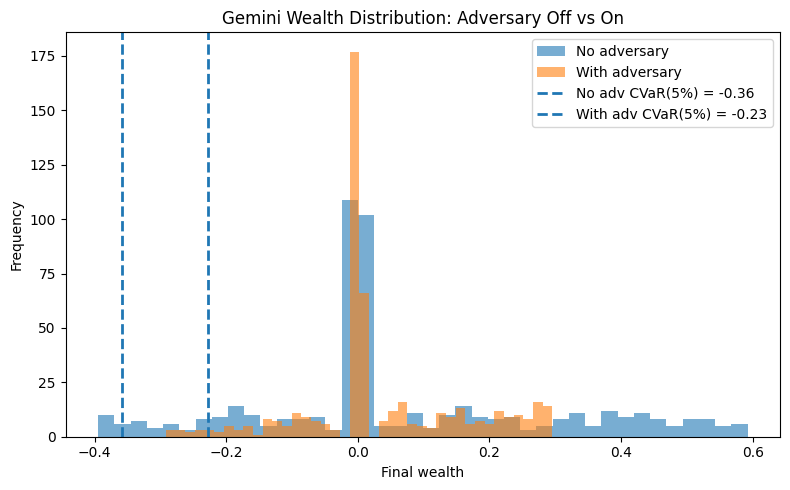

In [40]:
# Adversary on vs off comparison with CVaR
runs = 500

gemini_no_adv = []
gemini_adv = []

for i in range(runs):
    r1 = run_episode(seed=i, include_gemini=True, include_adversary=False)
    r2 = run_episode(seed=i, include_gemini=True, include_adversary=True)

    gemini_no_adv.append(r1["wealth"]["gemini"])
    gemini_adv.append(r2["wealth"]["gemini"])

# Compute CVaR
cvar_no = cvar(gemini_no_adv, alpha=0.05)
cvar_adv = cvar(gemini_adv, alpha=0.05)

plt.figure(figsize=(8,5))
plt.hist(gemini_no_adv, bins=40, alpha=0.6, label="No adversary")
plt.hist(gemini_adv, bins=40, alpha=0.6, label="With adversary")

plt.axvline(cvar_no, linestyle="--", linewidth=2, label=f"No adv CVaR(5%) = {cvar_no:.2f}")
plt.axvline(cvar_adv, linestyle="--", linewidth=2, label=f"With adv CVaR(5%) = {cvar_adv:.2f}")

plt.title("Gemini Wealth Distribution: Adversary Off vs On")
plt.xlabel("Final wealth")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


### Gemini Wealth Distribution: Adversary Off vs On

This plot compares Gemini’s final wealth distribution with and without an adversarial trader.
Dashed lines denote the 5% Conditional Value at Risk (CVaR).

**Key result:**  
While the adversary reduces mean wealth, it significantly improves tail risk.
CVaR shifts from approximately **−0.36 (no adversary)** to **−0.25 (with adversary)**.

This shows that tail risk in LMSR markets depends not only on belief accuracy,
but also on strategic interaction between agents.


## 4. Discussion
Across all experiments, expected value alone is a poor indicator of risk in LMSR-style prediction markets.

Even when agents achieve positive mean wealth, tail outcomes deteriorate sharply under belief misspecification, as captured by CVaR. Small belief errors leave average performance largely unchanged but expose agents to disproportionately large downside risk.

A risk-aware Gemini agent exhibits similar expected performance to the baseline Gemini agent, but does not significantly shift the left tail in this single-round setting. This indicates that linear position scaling is insufficient to mitigate outcome-driven losses when payoffs are resolved stochastically.

In contrast, strategic interaction materially alters tail behavior. Introducing an adversarial trader reduces directional concentration, leading to substantially improved worst-case and CVaR outcomes, even though expected value declines.

**Key takeaway:**
In LMSR markets, robustness depends not only on belief accuracy, but on risk sensitivity and agent interaction. Evaluating agents solely by expected value can be misleading; tail-risk diagnostics are essential for understanding real failure modes.